In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Function and its gradient
def f(x, y):
    return x**2 + y**2

def grad(x, y):
    return np.array([2*x, 2*y])

In [3]:
# Parameters
lr = 0.1
iterations = 20
x = 6
y =  -5  # Initial points for x and y
path = [(x, y, f(x, y))]

In [4]:
# Gradient Descent
for _ in range(iterations):
    dx, dy = grad(x, y)
    x -= lr * dx
    y -= lr * dy
    path.append((x, y, f(x, y)))

path = np.array(path)

In [5]:
# Create meshgrid for 3D surface
x_vals = np.linspace(-10, 10, 100)
y_vals = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)


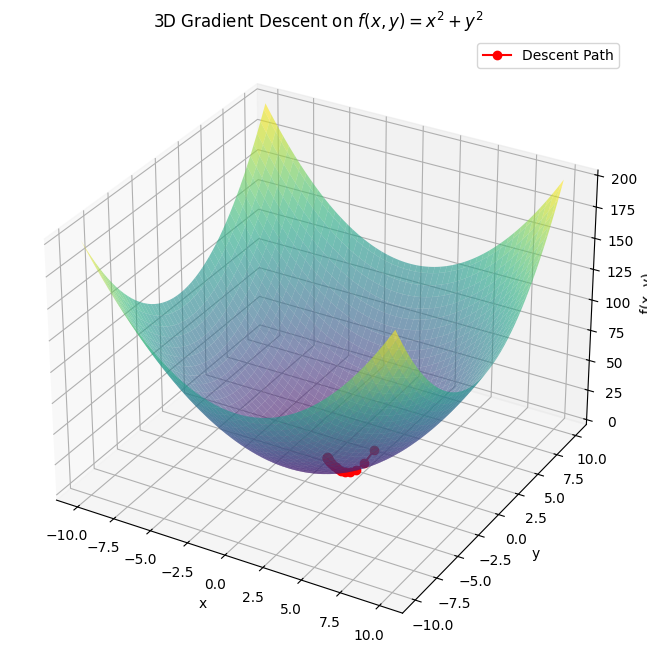

In [6]:
# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
ax.plot(path[:, 0], path[:, 1], path[:, 2], color='red', marker='o', label='Descent Path')
ax.set_title('3D Gradient Descent on $f(x, y) = x^2 + y^2$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()
plt.show()


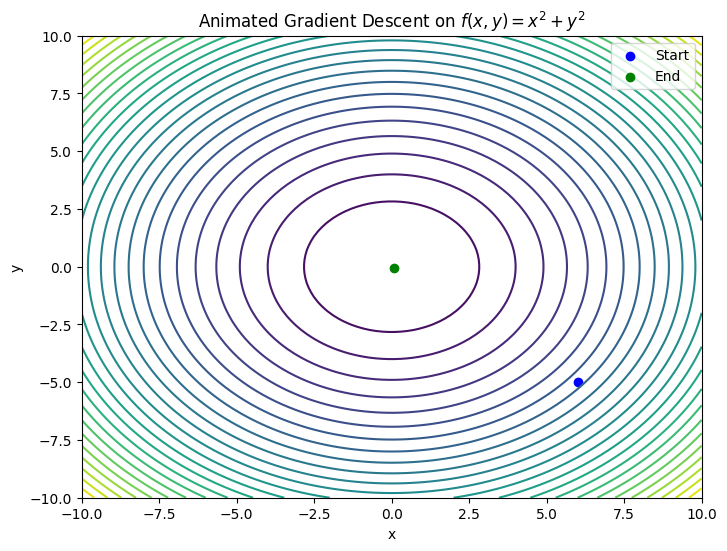

In [7]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contour(X, Y, Z, levels=30, cmap='viridis')
line, = ax.plot([], [], 'ro--')
start = ax.scatter(path[0, 0], path[0, 1], c='blue', label='Start')
end = ax.scatter(path[-1, 0], path[-1, 1], c='green', label='End')
ax.set_title('Animated Gradient Descent on $f(x, y) = x^2 + y^2$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()

def update(frame):
    line.set_data(path[:frame+1, 0], path[:frame+1, 1])
    return line,

ani = animation.FuncAnimation(fig, update, frames=len(path), interval=500)
plt.show()
